<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/KUIS1_244107020030_ATHAULLA_HAFIZH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [46]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [47]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [48]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [49]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [50]:
# Data Size
df.shape

(48842, 15)

In [51]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [52]:
# Jawab Soal 1
# 1. Inspeksi profile data
import numpy as np
# Cek nilai unik untuk melihat representasi missing value
# Pada dataset Adult, missing value berupa '?'
df.replace('?', np.nan, inplace=True)
print("--- Info Dataset ---")
df.info()

# 2. Variabel apa yang memiliki nilai yang hilang dan berapa jumlahnya?
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

--- Missing Values ---
workclass         2799
occupation        2809
na

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [53]:
# Jawab Soal 2
# 1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
# Fitur yang memiliki missing value adalah workclass, occupation, dan native-country (kategorikal)
# Imputasi data kategorikal dilakukan menggunakan Modus (Frequent Category)
for col in ['workclass', 'occupation', 'native-country']:
    modus = df[col].mode()[0]
    df[col].fillna(modus, inplace=True)

# 2. Cek kembali apakah masih terdapat data yang hilang
print("Total missing value setelah imputasi:", df.isnull().sum().sum())

Total missing value setelah imputasi: 0


/tmp/ipykernel_2660/2633954426.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(modus, inplace=True)


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [54]:
# Jawab Soal 3
# Inspeksi fitur kualitatif
kategorikal = df.select_dtypes(include=['object', 'category']).columns

# Penyesuaian duplikasi kesalahan penulisan pada kolom 'income'
# Terdapat label '>50K.' dan '<=50K.' yang seharusnya sama dengan '>50K' dan '<=50K'
df['income'] = df['income'].str.replace('.', '', regex=False)

# Penyesuaian pada kolom kualitatif yang nilainya tidak sesuai/minor, diganti dengan 'Others'
df['workclass'] = df['workclass'].replace(['Without-pay', 'Never-worked'], 'Others')
df['marital-status'] = df['marital-status'].replace(['Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'], 'Married')
df['marital-status'] = df['marital-status'].replace(['Divorced', 'Separated', 'Widowed'], 'Others')

print("Distribusi 'income' setelah diperbaiki:")
print(df['income'].value_counts())
print("\nDistribusi 'marital-status' setelah diperbaiki:")
print(df['marital-status'].value_counts())

Distribusi 'income' setelah diperbaiki:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Distribusi 'marital-status' setelah diperbaiki:
marital-status
Married          23044
Never-married    16117
Others            9681
Name: count, dtype: int64


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

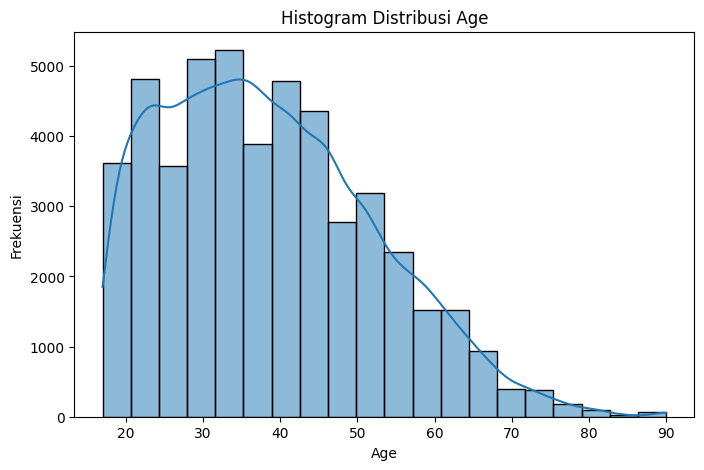

In [55]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Histogram Distribusi Age')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

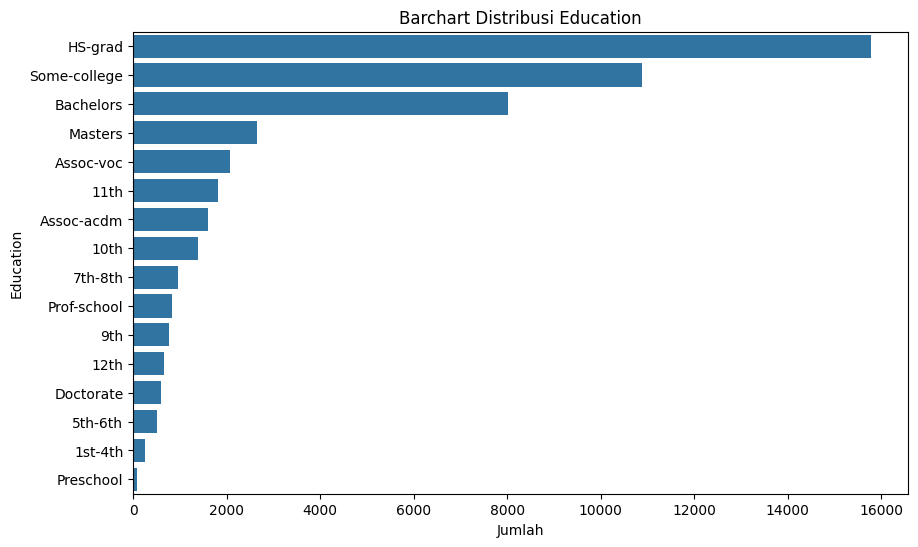

In [56]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(10, 6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title('Barchart Distribusi Education')
plt.xlabel('Jumlah')
plt.ylabel('Education')
plt.show()

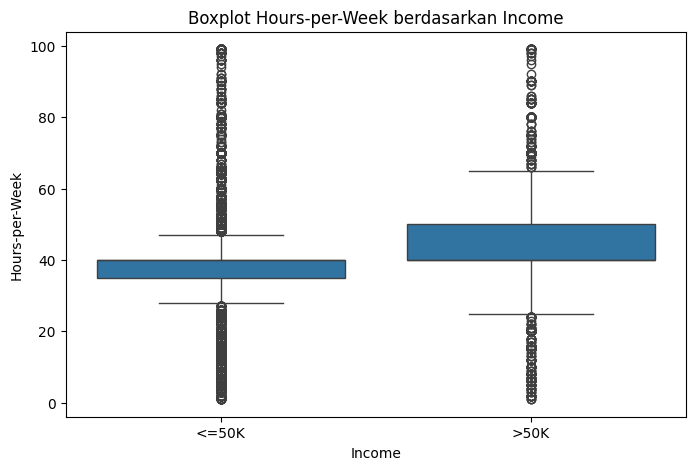

In [57]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title('Boxplot Hours-per-Week berdasarkan Income')
plt.xlabel('Income')
plt.ylabel('Hours-per-Week')
plt.show()

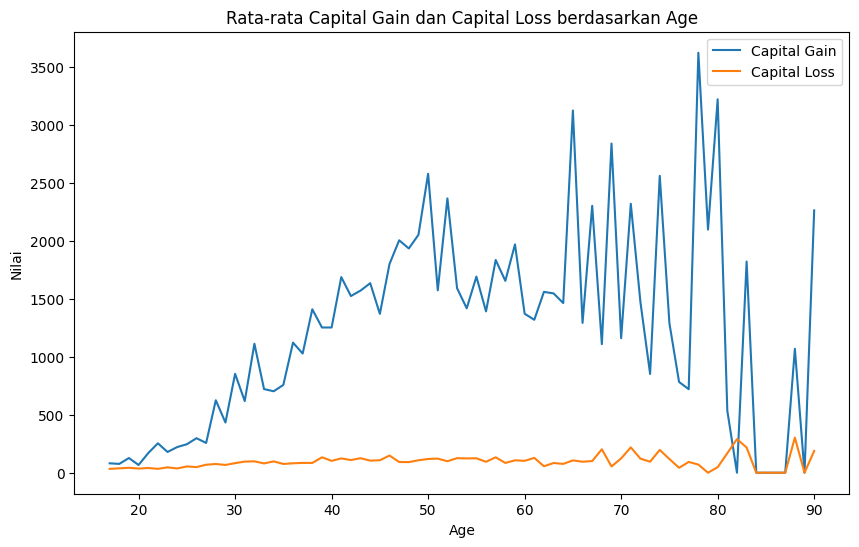

In [58]:
# Jawab 1.4 - Lineplot
# Aggregasi nilai mean berdasarkan umur terlebih dahulu
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='capital-gain', data=age_capital, label='Capital Gain')
sns.lineplot(x='age', y='capital-loss', data=age_capital, label='Capital Loss')
plt.title('Rata-rata Capital Gain dan Capital Loss berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Nilai')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [59]:
'''
1. Distribusi data 'age' cenderung Positive Skewness (miring ke kanan),
di mana sebagian besar subjek berada pada rentang usia 20 hingga 40 tahun,
dan frekuensinya semakin menurun seiring bertambahnya usia.

2. Jika terdapat data yang hilang pada variabel 'age', strategi imputasi yang paling
tepat adalah menggunakan nilai Median atau End of Tail.
Mengapa? Karena distribusi 'age' mengalami skew. Jika menggunakan Mean,
nilai rata-rata akan bias terpengaruh oleh nilai-nilai ekstrem pada usia sangat tua.

3. Berdasarkan boxplot, terdapat banyak titik-titik outlier pada kedua kategori
income (<=50K dan >50K) untuk variabel 'hours-per-week'. Kategori income '<=50K'
adalah yang paling banyak memiliki outlier, baik di bawah batas (q1-1.5*iqr) maupun
di atas batas (q3+1.5*iqr), menandakan variasi jam kerja di kelompok ini sangat beragam.
'''

"\n1. Distribusi data 'age' cenderung Positive Skewness (miring ke kanan), \ndi mana sebagian besar subjek berada pada rentang usia 20 hingga 40 tahun, \ndan frekuensinya semakin menurun seiring bertambahnya usia.\n\n2. Jika terdapat data yang hilang pada variabel 'age', strategi imputasi yang paling \ntepat adalah menggunakan nilai Median atau End of Tail.\nMengapa? Karena distribusi 'age' mengalami skew. Jika menggunakan Mean,\nnilai rata-rata akan bias terpengaruh oleh nilai-nilai ekstrem pada usia sangat tua.\n\n3. Berdasarkan boxplot, terdapat banyak titik-titik outlier pada kedua kategori \nincome (<=50K dan >50K) untuk variabel 'hours-per-week'. Kategori income '<=50K'\nadalah yang paling banyak memiliki outlier, baik di bawah batas (q1-1.5*iqr) maupun \ndi atas batas (q3+1.5*iqr), menandakan variasi jam kerja di kelompok ini sangat beragam.\n"

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [60]:
# Jawab Soal 1
# Encoding pada 'Sex' dan 'Income'
# Menggunakan Label Encoding

df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

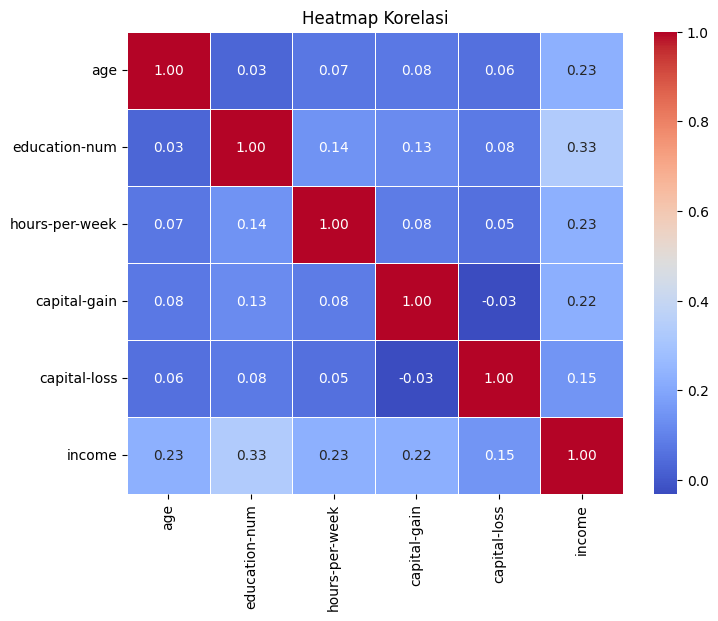

In [61]:
# Jawab Soal 1
# 1. Analisis Korelasi
kolom_korelasi = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
df_corr = df[kolom_korelasi].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

In [62]:
'''
2. Interpretasi Informasi dari Hasil Korelasi:
- Variabel 'education-num' dan 'income' memiliki nilai korelasi positif terbesar (0.33).
  Hal ini berarti bahwa semakin lama riwayat edukasi seseorang, semakin besar peluangnya mendapat income >50K.
- Variabel 'age', 'hours-per-week', dan 'capital-gain' juga berkorelasi positif terhadap 'income',
  namun dalam derajat yang moderat hingga lemah.
- Antar variabel independen (seperti age dan education-num) rata-rata korelasinya rendah,
  sehingga tidak ada masalah multikolinearitas yang serius pada dataset ini.
'''

"\n2. Interpretasi Informasi dari Hasil Korelasi:\n- Variabel 'education-num' dan 'income' memiliki nilai korelasi positif terbesar (0.33).\n  Hal ini berarti bahwa semakin lama riwayat edukasi seseorang, semakin besar peluangnya mendapat income >50K.\n- Variabel 'age', 'hours-per-week', dan 'capital-gain' juga berkorelasi positif terhadap 'income', \n  namun dalam derajat yang moderat hingga lemah. \n- Antar variabel independen (seperti age dan education-num) rata-rata korelasinya rendah,\n  sehingga tidak ada masalah multikolinearitas yang serius pada dataset ini.\n"

In [63]:
'''
Berdasarkan hasil korelasi, education-num memiliki hubungan positif paling besar dengan income (≈ 0,33). Artinya, semakin tinggi tingkat pendidikan, income cenderung lebih tinggi. age, hours-per-week, dan capital-gain juga memiliki hubungan positif terhadap income, tetapi lebih lemah. Sementara itu, capital-loss memiliki hubungan yang relatif rendah.
Secara umum, hubungan antarvariabel tidak terlalu kuat. Jadi, income tidak ditentukan oleh satu variabel saja, dan hasil korelasi ini hanya menunjukkan hubungan, bukan sebab-akibat.
'''

'\nBerdasarkan hasil korelasi, education-num memiliki hubungan positif paling besar dengan income (≈ 0,33). Artinya, semakin tinggi tingkat pendidikan, income cenderung lebih tinggi. age, hours-per-week, dan capital-gain juga memiliki hubungan positif terhadap income, tetapi lebih lemah. Sementara itu, capital-loss memiliki hubungan yang relatif rendah.\nSecara umum, hubungan antarvariabel tidak terlalu kuat. Jadi, income tidak ditentukan oleh satu variabel saja, dan hasil korelasi ini hanya menunjukkan hubungan, bukan sebab-akibat.\n'

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [64]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


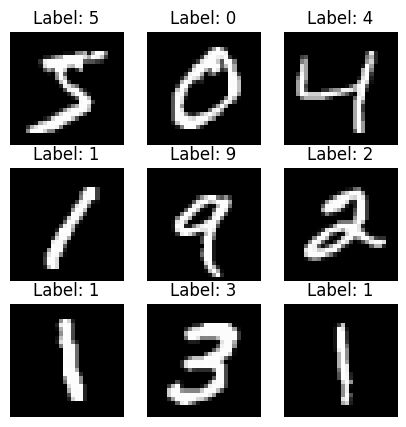

In [65]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

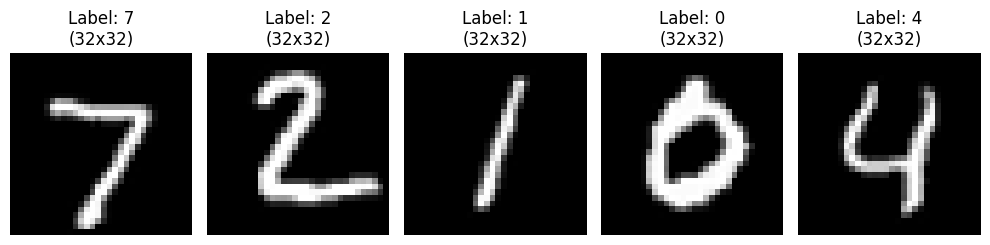

In [66]:
# Jawab Soal 1
import cv2

# 1. Membuat array kosong untuk menampung hasil upsampling sesuai hint
X_test_32 = np.zeros((X_test.shape[0], 32, 32))

for i in range(X_test.shape[0]):
    # Menggunakan cv2.INTER_CUBIC untuk hasil upsampling citra yang halus
    X_test_32[i] = cv2.resize(X_test[i], (32, 32), interpolation=cv2.INTER_CUBIC)

# 2. Tampilkan 5 data hasil proses upsampling
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_32[i], cmap="gray")
    plt.title(f"Label: {y_test[i]}\n(32x32)")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [67]:
# Jawab Soal 2
# Normalisasi nilai citra rentang 0-1 (Min-Max Normalization)
X_test_norm = X_test_32 / 255.0

print(f"Nilai minimum setelah normalisasi: {X_test_norm.min()}")
print(f"Nilai maksimum setelah normalisasi: {X_test_norm.max()}")

Nilai minimum setelah normalisasi: 0.0
Nilai maksimum setelah normalisasi: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [68]:
# Jawab Soal 3
# Ubah matriks citra menjadi array 1 dimensi (flattening)

# Membuat holder array kosong untuk menampung hasilnya sesuai hint
X_test_flat = np.zeros((X_test_norm.shape[0], 32 * 32))

for i in range(X_test_norm.shape[0]):
    X_test_flat[i] = X_test_norm[i].flatten()

print("Bentuk matriks sebelum flattening:", X_test_norm.shape)
print("Bentuk matriks setelah flattening:", X_test_flat.shape)

Bentuk matriks sebelum flattening: (10000, 32, 32)
Bentuk matriks setelah flattening: (10000, 1024)
